In [1]:
import numpy as np
import torch
import cv2
import os
from sam2.build_sam import build_sam2
from sam2.sam2_image_predictor import SAM2ImagePredictor

In [2]:
import os

data_dir = r"LabPicsV1//"  # Path to dataset (LabPics 1)
data = []  # List to store dataset entries

# List all files in the Image and Instance folders
image_files = os.listdir(data_dir + "Simple/Train/Image/")
instance_files = os.listdir(data_dir + "Simple/Train/Instance/")

# Count of images and instances
print("Total images in Image folder:", len(image_files))
print("Total annotations in Instance folder:", len(instance_files))

# Iterate over all files in the Image folder
for name in image_files:
    # Get the base name without the extension
    base_name = os.path.splitext(name)[0]  # Removes the file extension

    # Define the paths for image and annotation files
    image_path = os.path.join(data_dir, "Simple/Train/Image", name)
    annotation_path = os.path.join(data_dir, "Simple/Train/Instance", base_name + ".png")

    # Check if the annotation file exists before adding to the data list
    if os.path.exists(annotation_path):
        data.append({"image": image_path, "annotation": annotation_path})

# Print the count of matched image-annotation pairs
print("Matched image-annotation pairs:", len(data))


Total images in Image folder: 19724
Total annotations in Instance folder: 19725
Matched image-annotation pairs: 19724


In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def read_batch(data):  # read random image and its annotation from the dataset

    # Select a random image
    ent = data[np.random.randint(len(data))]  # choose random entry
    Img = cv2.imread(ent["image"])[..., ::-1]  # read image in RGB format
    ann_map = cv2.imread(ent["annotation"])  # read annotation in BGR format

    # Resize image
    r = np.min([1024 / Img.shape[1], 1024 / Img.shape[0]])  # scaling factor
    Img = cv2.resize(Img, (int(Img.shape[1] * r), int(Img.shape[0] * r)))
    ann_map = cv2.resize(ann_map, (int(ann_map.shape[1] * r), int(ann_map.shape[0] * r)),
                         interpolation=cv2.INTER_NEAREST)
    # Define mat_map (road area) as binary mask where blue pixels (road) are set to 1
    mat_map = ((ann_map[:, :, 0] > 10) & (ann_map[:, :, 1] < 125) & (ann_map[:, :, 2] < 125)).astype(np.uint8)

    
    # Apply morphological closing to fill small gaps in the road mask
    kernel = np.ones((5, 5), np.uint8)  # You can adjust the kernel size
    mat_map = cv2.morphologyEx(mat_map, cv2.MORPH_CLOSE, kernel)

    # Define a kernel size
    kernel = np.ones((3, 3), np.uint8)  # Adjust size based on needs

    # Apply dilation to expand road areas
    mat_map = cv2.dilate(mat_map, kernel, iterations=1)

    # Get binary masks and points
    inds = np.unique(mat_map)[1:]  # load all indices except background
    points = []
    masks = []
    for ind in inds:
        mask = (mat_map == ind).astype(np.uint8)  # make binary mask corresponding to index ind

        masks.append(mask)
        coords = np.argwhere(mask > 0)  # get all coordinates in mask
        yx = np.array(coords[np.random.randint(len(coords))])  # choose random point/coordinate
        points.append([[yx[1], yx[0]]])


    return Img, np.array(masks), np.array(points), np.ones([len(masks), 1])



[[[1004  276]]]


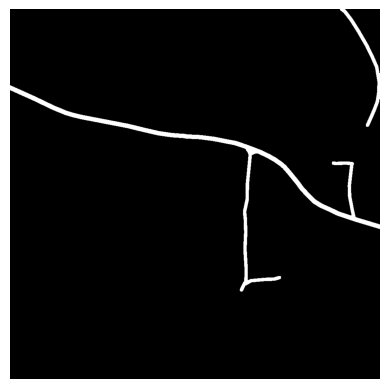

In [4]:
import matplotlib.pyplot as plt
img, mask, point, other = read_batch(data)
print(point)
plt.imshow(np.squeeze(mask), cmap='gray')
plt.axis('off')  # Turn off axis labels
plt.show()



In [5]:
sam2_checkpoint = "sam2_hiera_large.pt" # path to model weight (pre model loaded from: https://dl.fbaipublicfiles.com/segment_anything_2/072824/sam2_hiera_small.pt)
model_cfg = "sam2_hiera_l.yaml" #  model config
sam2_model = build_sam2(model_cfg, sam2_checkpoint, device="cuda") # load model
predictor = SAM2ImagePredictor(sam2_model)

In [6]:
predictor.model.sam_mask_decoder.train(True) # enable training of mask decoder
predictor.model.sam_prompt_encoder.train(True) # enable training of prompt encoder
'''
#The main part of the net is the image encoder, if you have good GPU you can enable training of this part by using:
predictor.model.image_encoder.train(True)
#Note that for this case, you will also need to scan the SAM2 code for “no_grad” commands and remove them (“ no_grad” blocks the gradient collection, which saves memory but prevents training).
'''
optimizer=torch.optim.AdamW(params=predictor.model.parameters(),lr=1e-5,weight_decay=4e-5)
scaler = torch.cuda.amp.GradScaler() # mixed precision

In [ ]:
import os
import cv2
import numpy as np
import torch
import random
import matplotlib.pyplot as plt

# Function to read validation images and labels
def load_validation_data(image_folder, label_folder):
    image_paths = sorted([os.path.join(image_folder, fname) for fname in os.listdir(image_folder) if fname.endswith('.jpg') or fname.endswith('.png')])
    label_paths = sorted([os.path.join(label_folder, fname) for fname in os.listdir(label_folder) if fname.endswith('.jpg') or fname.endswith('.png')])
    return image_paths, label_paths

# Function to get random points from mask
def get_random_points_from_mask(mask, num_points=1):
    y_indices, x_indices = np.where(mask > 0)
    if len(y_indices) == 0:
        height, width = mask.shape
        points = np.array([(random.randint(0, width - 1), random.randint(0, height - 1)) for _ in range(num_points)])
    else:
        indices = random.choices(range(len(y_indices)), k=num_points)
        points = np.array([(x_indices[i], y_indices[i]) for i in indices])
    return points

# Paths to validation folders
val_label_folder = "LabPicsV1/verify_label"
val_image_folder = "LabPicsV1/verify_image"
# Load validation data paths
val_image_paths, val_label_paths = load_validation_data(val_image_folder, val_label_folder)

# List to store validation scores
validation_scores = []

for itr in range(50000):
    # Training Step

    with torch.cuda.amp.autocast():  # Mixed precision
        
        image, mask, input_point, input_label = read_batch(data) # Load training image and mask
        if mask.shape[0] == 0: continue # Skip if no mask is found
        predictor.set_image(image)

        # Prompt Encoding
        mask_input, unnorm_coords, labels, unnorm_box = predictor._prep_prompts(input_point, input_label, box=None, mask_logits=None, normalize_coords=True) # Prepare prompts
        sparse_embeddings, dense_embeddings = predictor.model.sam_prompt_encoder(points=(unnorm_coords, labels), boxes=None, masks=None) # Prompt encoding
        # Mask Decoder
        batched_mode = unnorm_coords.shape[0] > 1 # Check if batched mode is enabled
        high_res_features = [feat_level[-1].unsqueeze(0) for feat_level in predictor._features["high_res_feats"]] # High resolution features
        low_res_masks, prd_scores, _, _ = predictor.model.sam_mask_decoder(
            image_embeddings=predictor._features["image_embed"][-1].unsqueeze(0),
            image_pe=predictor.model.sam_prompt_encoder.get_dense_pe(),
            sparse_prompt_embeddings=sparse_embeddings,
            dense_prompt_embeddings=dense_embeddings,
            multimask_output=False,
            repeat_image=batched_mode,
            high_res_features=high_res_features,
        ) # Mask decoder
        prd_masks = predictor._transforms.postprocess_masks(low_res_masks, predictor._orig_hw[-1]) # Post-process masks
        
        # Segmentation Loss Calculation
        gt_mask = torch.tensor(mask.astype(np.float32)).cuda()
        prd_mask = torch.sigmoid(prd_masks[:, 0])
        seg_loss = (-gt_mask * torch.log(prd_mask + 1e-5) - (1 - gt_mask) * torch.log((1 - prd_mask) + 1e-5)).mean()

        # IoU Calculation
        inter = (gt_mask * (prd_mask > 0.5)).sum(1).sum(1)
        iou = inter / (gt_mask.sum(1).sum(1) + (prd_mask > 0.5).sum(1).sum(1) - inter)
        score_loss = torch.abs(prd_scores[:, 0] - iou).mean()
        loss = seg_loss + score_loss * 0.05

        # Backpropagation
        predictor.model.zero_grad()
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        
        # Save Model and Display Training Metrics
        if itr % 2000 == 0:
            model_path = f"model_{itr // 1000 + 1}.torch"
            torch.save(predictor.model.state_dict(), model_path)
            print(f"Model saved as {model_path} at iteration {itr}")

        if itr == 0: mean_iou = 0
        mean_iou = mean_iou * 0.99 + 0.01 * np.mean(iou.cpu().detach().numpy())
        print("Step:", itr, "Training Accuracy (IoU):", mean_iou)

    # Validation Step
    if itr % 2000 == 0 and itr > 0:
        predictor.model.eval()  # Set model to evaluation mode
        val_mean_iou = 0

        with torch.no_grad():
            for val_image_path, val_label_path in zip(val_image_paths, val_label_paths):
                # Load validation image and label
                val_image = cv2.imread(val_image_path)[..., ::-1].copy()  # Convert BGR to RGB and avoid negative strides
                #val_image = torch.tensor(val_image).permute(2, 0, 1).unsqueeze(0).cuda().half()
                #val_mask = cv2.imread(val_label_path, cv2.IMREAD_GRAYSCALE)  # Binary mask
                val_label = cv2.imread(val_label_path, cv2.IMREAD_COLOR)  # Load label in color

                val_mask = ((val_label[:, :, 0] > 0) &  # Blue channel is 255
                (val_label[:, :, 1] < 125) &    # Green channel is 0
                (val_label[:, :, 2] < 125)).astype(np.uint8)  # Red channel is 0
                
                predictor.set_image(val_image)

                # Generate random points based on the binary mask
                input_points = get_random_points_from_mask(val_mask, num_points=5)
                input_point = np.array([input_points])
                input_label = np.ones((1, len(input_points)), dtype=int)  # Labels set to 1 (foreground)

                # Prompt Encoding and Mask Decoding
                mask_input, unnorm_coords, labels, unnorm_box = predictor._prep_prompts(
                    input_point, input_label, box=None, mask_logits=None, normalize_coords=True
                )
                sparse_embeddings, dense_embeddings = predictor.model.sam_prompt_encoder(
                    points=(unnorm_coords, labels), boxes=None, masks=None
                )

                # Mask Decoder for Validation
                val_batched_mode = unnorm_coords.shape[0] > 1
                val_high_res_features = [feat_level[-1].unsqueeze(0) for feat_level in predictor._features["high_res_feats"]]
                val_low_res_masks, val_prd_scores, _, _ = predictor.model.sam_mask_decoder(
                    image_embeddings=predictor._features["image_embed"][-1].unsqueeze(0),
                    image_pe=predictor.model.sam_prompt_encoder.get_dense_pe(),
                    sparse_prompt_embeddings=sparse_embeddings,
                    dense_prompt_embeddings=dense_embeddings,
                    multimask_output=False,
                    repeat_image=val_batched_mode,
                    high_res_features=val_high_res_features,
                )
                val_prd_masks = predictor._transforms.postprocess_masks(val_low_res_masks, predictor._orig_hw[-1])

                # Validation IoU Calculation
                val_gt_mask = torch.tensor(val_mask.astype(np.float32)).cuda()
                val_prd_mask = torch.sigmoid(val_prd_masks[:, 0])
                val_inter = (val_gt_mask * (val_prd_mask > 0.5)).sum()
                val_union = val_gt_mask.sum() + (val_prd_mask > 0.5).sum() - val_inter
                val_iou = val_inter / val_union
                val_mean_iou = val_mean_iou * 0.99 + 0.01 * np.mean(val_iou.cpu().detach().numpy())

            print(f"Validation IoU after iteration {itr}: {val_mean_iou}")

            # Store validation IoU score
            validation_scores.append(val_mean_iou)

        predictor.model.train()  # Return to training mode for the next iteration

# Plot validation scores after training
plt.plot(range(1, len(validation_scores) + 1), validation_scores, marker='o')
plt.xlabel("Validation Step (x1000 iterations)")
plt.ylabel("Validation IoU Score")
plt.title("Validation IoU Scores over Training")
plt.show()


c:\Users\ahmed\Downloads\Test_UNET\fine-tune-train_segment_anything_2_in_60_lines_of_code-main\fine-tune-train_segment_anything_2_in_60_lines_of_code-main\sam2\modeling\backbones\hieradet.py:72: UserWarning: 1Torch was not compiled with flash attention. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\native\transformers\cuda\sdp_utils.cpp:555.)
  x = F.scaled_dot_product_attention(


Model saved as model_1.torch at iteration 0
Step: 0 Training Accuracy (IoU): 9.018777869641781e-05
Step: 1 Training Accuracy (IoU): 0.0001424831441603601
Step: 2 Training Accuracy (IoU): 0.005723276482884772
Step: 3 Training Accuracy (IoU): 0.006165050451354227
Step: 4 Training Accuracy (IoU): 0.006364753126653116
Step: 5 Training Accuracy (IoU): 0.007858801461017688
Step: 6 Training Accuracy (IoU): 0.008496189580350115
Step: 7 Training Accuracy (IoU): 0.008832523372102882
Step: 8 Training Accuracy (IoU): 0.010420698727037325
Step: 9 Training Accuracy (IoU): 0.010422457519861218
Step: 10 Training Accuracy (IoU): 0.010364023765976463
Step: 11 Training Accuracy (IoU): 0.0135645273743517
Step: 12 Training Accuracy (IoU): 0.015744722076680494
Step: 13 Training Accuracy (IoU): 0.015636047185378244
Step: 14 Training Accuracy (IoU): 0.01743479252488196
Step: 15 Training Accuracy (IoU): 0.017319518707190673
Step: 16 Training Accuracy (IoU): 0.017163147522496456
Step: 17 Training Accuracy (IoU)

In [11]:
print(validation_scores)

[0.23894945253287722, 0.27801078037694016, 0.2900998987850799, 0.29059116991527467, 0.2945565853240477, 0.30820540676997554, 0.29110123139344696, 0.3026101036069804, 0.31025659498916874, 0.3190053895258236, 0.32600611218654724, 0.3203759300180062, 0.31020544725206384, 0.33277637892473494, 0.32729011691059373, 0.31248966751485563, 0.3184717984211353, 0.31505009344440016, 0.31922029389951206, 0.3212874736478698, 0.29719825090822766, 0.27158010013127765, 0.3139903327096794, 0.2753319183985083]


In [14]:
# use bfloat16 for the entire script (memory efficient)
torch.autocast(device_type="cuda", dtype=torch.bfloat16).__enter__()


# Load image

image_path = "result_nocrop.jpg"
mask_path="white_mask.png"
num_samples = 0 # number of points/segment to sample


In [15]:
def read_image(image_path, mask_path): # read and resize image and mask
        img = cv2.imread(image_path)[...,::-1]  # read image
        mask = cv2.imread(mask_path,0)
        r = np.min([1024 / img.shape[1], 1024 / img.shape[0]]) # scaling factor
        img = cv2.resize(img, (int(img.shape[1] * r), int(img.shape[0] * r))) # resize image
        mask = cv2.resize(mask, (int(mask.shape[1] * r), int(mask.shape[0] * r)),interpolation=cv2.INTER_NEAREST)  # resize mask
        return img, mask


def get_points(mask,num_points): # Sample points inside the input mask
        points=[]
        for i in range(num_points):
            coords = np.argwhere(mask > 0)
            yx = np.array(coords[np.random.randint(len(coords))])
            points.append([[yx[1], yx[0]]])
        return np.array(points)


In [16]:
# read image and sample points
image,mask = read_image(image_path, mask_path)
input_points = get_points(mask,num_samples)



In [17]:
# Load model you need to have pretrained model already made
sam2_checkpoint = "sam2_hiera_small.pt" # "sam2_hiera_large.pt"
model_cfg = "sam2_hiera_s.yaml" # "sam2_hiera_l.yaml"
sam2_model = build_sam2(model_cfg, sam2_checkpoint, device="cuda") # load model


In [18]:
# Build net and load weights
predictor = SAM2ImagePredictor(sam2_model) # build predictor
predictor.model.load_state_dict(torch.load("50kitrFULLdataset/model_25.torch")) #25 22


<All keys matched successfully>

In [ ]:
import os
import numpy as np
import cv2
import torch

##### INFERENCE FOR STATIC IMAGE #####

# Ensure the output directory exists
output_dir = "report_images"
os.makedirs(output_dir, exist_ok=True)

# Predict mask
with torch.no_grad():
    predictor.set_image(image)
    masks, scores, logits = predictor.predict(
        point_coords=None,
        point_labels=None,
    )

# Sort predicted masks from high to low score
np_masks = np.array(masks)  # Convert masks to numpy array
np_scores = scores  # Extract scores
sorted_masks = np_masks[np.argsort(np_scores)][::-1]  # Sort by scores in descending order

print(sorted_masks.shape)
print(np_masks.shape)
print(scores.shape)

# Stitch predicted mask into one segmentation mask
seg_map = np.zeros_like(sorted_masks[0], dtype=np.uint8)
occupancy_mask = np.zeros_like(sorted_masks[0], dtype=bool)

for i in range(sorted_masks.shape[0]):
    mask = sorted_masks[i]
    if (mask * occupancy_mask).sum() / mask.sum() > 0.15:
        continue
    mask[occupancy_mask] = 0
    seg_map[mask > 0.5] = i + 1  # Threshold for positive prediction
    occupancy_mask[mask > 0.1] = 1

print(seg_map)

# Create colored annotation map
height, width = seg_map.shape
rgb_image = np.zeros((height, width, 3), dtype=np.uint8)

# Assign random colors to each class
for id_class in range(1, seg_map.max() + 1):
    rgb_image[seg_map == id_class] = [
        np.random.randint(255),
        np.random.randint(255),
        np.random.randint(255),
    ]

# Blend the annotation map with the original image
blended_image = (rgb_image / 2 + image / 2).astype(np.uint8)

# Save the images in the output directory
cv2.imwrite(os.path.join(output_dir, "annotation.png"), rgb_image)
cv2.imwrite(os.path.join(output_dir, "mix.png"), blended_image)
cv2.imwrite(os.path.join(output_dir, "image.png"), image)

# Display the images
cv2.imshow('RGB Image', cv2.resize(rgb_image, (800, 600)))
cv2.imshow('Blended Image', cv2.resize(blended_image, (800, 600)))
cv2.imshow('Original Image', image)

# Wait for a key press and close all windows
cv2.waitKey()
cv2.destroyAllWindows()


c:\Users\ahmed\Downloads\Test_UNET\fine-tune-train_segment_anything_2_in_60_lines_of_code-main\fine-tune-train_segment_anything_2_in_60_lines_of_code-main\sam2\modeling\backbones\hieradet.py:72: UserWarning: 1Torch was not compiled with flash attention. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\native\transformers\cuda\sdp_utils.cpp:555.)
  x = F.scaled_dot_product_attention(


(3, 1024, 966)
(3, 1024, 966)
(3,)
[[1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]
 ...
 [1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]]


In [20]:
import os

def parse_detection_file(file_path):
    """
    Parse a detection TXT file, ignoring the last two elements in each line.

    Args:
        file_path (str): Path to the detection TXT file.

    Returns:
        list: A list of detections, where each detection is a tuple:
              (x1, y1, x2, y2, x3, y3, x4, y4).
    """
    detections = []
    
    if not os.path.exists(file_path):
        print(f"File not found: {file_path}")
        return detections  # Return empty list if file doesn't exist

    with open(file_path, 'r') as f:
        for line in f:
            try:
                # Split line by commas and take only the first 8 elements
                parts = line.strip().split(',')
                if len(parts) < 10:  # Ensure there are at least 10 elements
                    print(f"Skipping malformed line: {line}")
                    continue
                
                # Extract bounding box coordinates (first 8 elements)
                x1, y1, x2, y2, x3, y3, x4, y4 = map(int, parts[:8])

                # Append to detections list
                detections.append((x1, y1, x2, y2, x3, y3, x4, y4))
            except ValueError:
                print(f"Skipping line with invalid values: {line}")

    return detections


In [14]:
import os
import numpy as np
import cv2
import torch

##### INFERENCE FOR VIDEO #####

# Load the pretrained SAM2 model
device = "cuda" if torch.cuda.is_available() else "cpu"

# Path to the input video
input_video_path = "/Users/ahmed/Desktop/PDS MA3/DJI_0763.MOV"

# Directory containing the detection TXT files
detections_dir = "/Users/ahmed/Downloads/DJI_0763_detection"

# Radius around cars to remove pixels from the mask
radius = 125

# Output video writer for "mask video"
output_video_path = "output_mask_video.avi"

# Open the video file
cap = cv2.VideoCapture(input_video_path)

# Get video properties
frame_width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
frame_height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = int(cap.get(cv2.CAP_PROP_FPS))

fourcc = cv2.VideoWriter_fourcc(*'XVID')  # Codec for the output video
out = cv2.VideoWriter(output_video_path, fourcc, fps, (frame_width, frame_height))

# Function to parse detection files
def parse_detection_file(file_path):
    detections = []
    if not os.path.exists(file_path):
        print(f"File not found: {file_path}")
        return detections

    with open(file_path, 'r') as f:
        for line in f:
            try:
                parts = line.strip().split(',')
                if len(parts) < 10:  # Ensure there are at least 10 elements
                    print(f"Skipping malformed line: {line}")
                    continue
                
                x1, y1, x2, y2, x3, y3, x4, y4 = map(int, parts[:8])
                detections.append((x1, y1, x2, y2, x3, y3, x4, y4))
            except ValueError:
                print(f"Skipping line with invalid values: {line}")

    return detections

# Main inference loop
frame_number = 0
while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    # Load detections for the current frame
    detection_file = os.path.join(detections_dir, f"det_fr_{frame_number:04d}.txt")
    detections = parse_detection_file(detection_file)

    # Predict mask for the current frame
    with torch.no_grad():
        predictor.set_image(frame)
        masks, scores, logits = predictor.predict(
            point_coords=None,
            point_labels=None
        )

    # Process the predicted masks
    np_masks = np.array(masks)  # Convert masks to numpy array
    np_scores = scores
    sorted_masks = np_masks[np.argsort(np_scores)][::-1]

    # Stitch predicted masks into one segmentation mask
    seg_map = np.zeros_like(sorted_masks[0], dtype=np.uint8)
    occupancy_mask = np.zeros_like(sorted_masks[0], dtype=bool)
    for i in range(sorted_masks.shape[0]):
        mask = sorted_masks[i]
        if (mask * occupancy_mask).sum() / mask.sum() > 0.15:
            continue
        mask[occupancy_mask] = 0
        seg_map[mask > 0.5] = i + 1
        occupancy_mask[mask > 0.5] = 1

    # Modify the mask to keep only pixels within the square around detected cars
    combined_car_mask = np.zeros_like(seg_map, dtype=np.uint8)

    for detection in detections:
        x1, y1, x2, y2, x3, y3, x4, y4 = detection
        # Calculate the center of the bounding box
        center_x = (x1 + x2 + x3 + x4) // 4
        center_y = (y1 + y2 + y3 + y4) // 4

        # Define the top-left and bottom-right corners of the square
        top_left = (max(center_x - radius, 0), max(center_y - radius, 0))
        bottom_right = (min(center_x + radius, seg_map.shape[1] - 1), min(center_y + radius, seg_map.shape[0] - 1))

        # Add a square region for the car to the combined mask
        cv2.rectangle(combined_car_mask, top_left, bottom_right, 1, -1)

    # Retain only pixels in the segmentation mask within the car square mask
    seg_map = np.where(combined_car_mask, seg_map, 0)

    # Post-processing: Fill holes and remove noise
    kernel_size_erosion = 15  # Adjust based on noise and gap sizes
    kernel_noise = np.ones((kernel_size_erosion, kernel_size_erosion), np.uint8)

    kernel_size_expansion = 100
    kernel_square = np.ones((kernel_size_expansion, kernel_size_expansion), np.uint8)

    # Fill small holes
    
    final_mask = cv2.morphologyEx(seg_map, cv2.MORPH_OPEN, kernel_noise)
    
    filled_mask = cv2.morphologyEx(final_mask, cv2.MORPH_CLOSE, kernel_square)

    # Remove small noise
    

    # Replace seg_map with the processed final mask
    seg_map = filled_mask

    # Create colored annotation map
    height, width = seg_map.shape
    rgb_image = np.zeros((height, width, 3), dtype=np.uint8)

    for id_class in range(1, seg_map.max() + 1):
        rgb_image[seg_map == id_class] = [255,0,0]

    # Blend the original frame with the colored annotation map
    blended_image = (rgb_image / 2 + frame / 2).astype(np.uint8)

    # Write the blended frame to the output video
    out.write(blended_image)

    # Display the original video and the mask video side by side (smaller)
    scale = 0.5  # Scale factor for resizing
    small_frame = cv2.resize(frame, (int(frame_width * scale), int(frame_height * scale)))
    small_blended = cv2.resize(blended_image, (int(frame_width * scale), int(frame_height * scale)))

    # Combine the resized frames side by side
    combined_display = np.hstack((small_frame, small_blended))

    # Show the resized combined display
    cv2.imshow('Video (Original | Mask)', combined_display)

    if cv2.waitKey(1) & 0xFF == ord('q'):  # Press 'q' to exit
        break

    frame_number += 1

# Release resources
cap.release()
out.release()
cv2.destroyAllWindows()


c:\Users\ahmed\Downloads\Test_UNET\fine-tune-train_segment_anything_2_in_60_lines_of_code-main\fine-tune-train_segment_anything_2_in_60_lines_of_code-main\sam2\modeling\backbones\hieradet.py:72: UserWarning: 1Torch was not compiled with flash attention. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\native\transformers\cuda\sdp_utils.cpp:555.)
  x = F.scaled_dot_product_attention(
